In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pyvinecopulib as pv
from matplotlib.lines import Line2D
from scipy.stats import norm


def copula_params(family: str, tau: float, nu: int = 4) -> dict[str, float]:
  if family == "clayton":
    return {"theta": 2.0 * tau / (1.0 - tau)}
  if family == "gumbel":
    return {"theta": 1.0 / (1.0 - tau)}
  if family in {"gaussian", "student"}:
    params = {"rho": np.sin(np.pi * tau / 2.0)}
    if family == "student":
      params["nu"] = float(nu)
    return params
  raise ValueError(f"Unknown family: {family}")


def set_bicop(family: str, params: dict[str, float]) -> pv.Bicop:
  if family == "clayton":
    return pv.Bicop(
      family=pv.BicopFamily.clayton,
      rotation=0,
      parameters=np.array([[params["theta"]]], dtype=float),
    )
  if family == "gumbel":
    return pv.Bicop(
      family=pv.BicopFamily.gumbel,
      rotation=0,
      parameters=np.array([[params["theta"]]], dtype=float),
    )
  if family == "gaussian":
    return pv.Bicop(
      family=pv.BicopFamily.gaussian,
      parameters=np.array([[params["rho"]]], dtype=float),
    )
  if family == "student":
    return pv.Bicop(
      family=pv.BicopFamily.student,
      parameters=np.array([[params["rho"]], [params["nu"]]], dtype=float),
    )
  raise ValueError(f"Unknown family: {family}")


def sample_bicop(
  n: int, seed: int, family: str, spec: dict[str, float]
) -> np.ndarray:
  bicop = set_bicop(family, copula_params(family, **spec))
  return bicop.simulate(n, seeds=[seed])


def make_patchwork_sample(
  n_bg: int = 3000,
  n_patch_a: int = 400,
  n_patch_b: int = 400,
  seed: int = 7,
  q: float = 0.10,
):
  """
  Visualization-only patchwork sample.

  - background: weak Gaussian copula over the full unit square
  - patch A: strong Clayton, mapped to the lower triangle inside [0, q]^2
  - patch B: Student-t, mapped to the upper triangle inside [0, q]^2
  """
  rng = np.random.default_rng(seed)

  # Weak background dependence
  bg = sample_bicop(n_bg, seed, "clayton", {"tau": 0.50})
  bg_labels = np.full(n_bg, "Outside", dtype=object)

  # Patch A: lower triangle u2 <= u1 in the lower-left square
  a = sample_bicop(n_patch_a, seed + 101, "clayton", {"tau": 0.4})
  a = q * a
  a = np.sort(a, axis=1)[:, ::-1]  # enforce u1 >= u2

  # Patch B: upper triangle u2 > u1 in the lower-left square
  b = sample_bicop(n_patch_b, seed + 202, "student", {"tau": 0.4, "nu": 4})
  b = q * b
  b = np.sort(b, axis=1)  # enforce u2 >= u1

  # Add a tiny jitter so the diagonal split looks less artificial
  jitter = 0.002 * q
  a = np.clip(a + rng.normal(scale=jitter, size=a.shape), 0.0, q)
  b = np.clip(b + rng.normal(scale=jitter, size=b.shape), 0.0, q)

  a_labels = np.full(n_patch_a, "Patch A", dtype=object)
  b_labels = np.full(n_patch_b, "Patch B", dtype=object)

  u = np.vstack([bg, a, b])
  labels = np.concatenate([bg_labels, a_labels, b_labels])

  return u, labels


def to_gaussian_space(u: np.ndarray, eps: float = 1e-6) -> np.ndarray:
  return norm.ppf(np.clip(u, eps, 1.0 - eps))


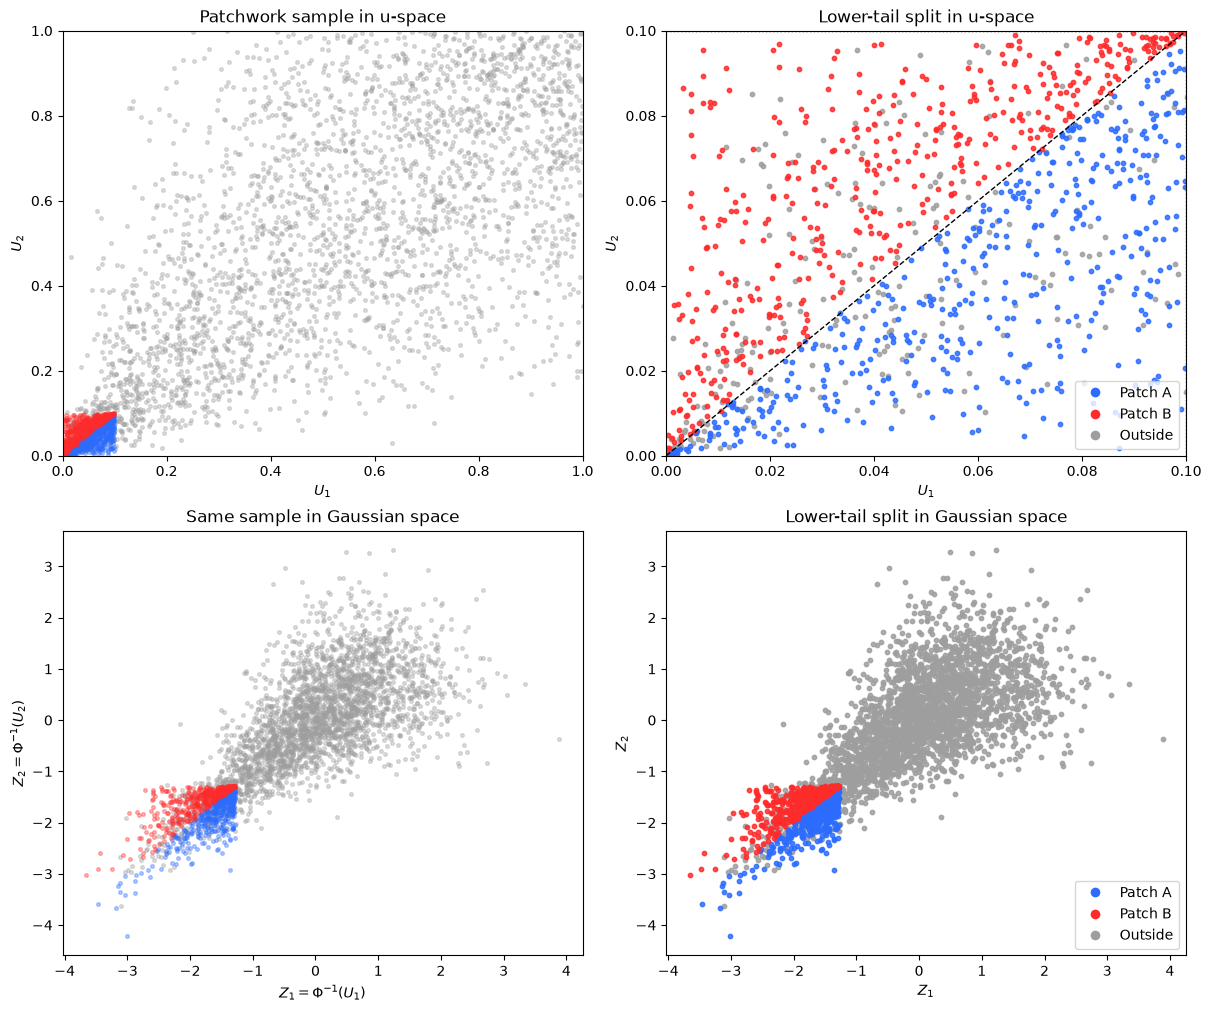

In [3]:
q = 0.10
u, labels = make_patchwork_sample(
  n_bg=3000,
  n_patch_a=450,
  n_patch_b=450,
  seed=7,
  q=q,
)
z = to_gaussian_space(u)

colors = {
  "Outside": "#9e9e9e",
  "Patch A": "#2b6cff",
  "Patch B": "#ff2b2b",
}

legend_handles = [
  Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor=colors["Patch A"],
    markersize=8,
    label="Patch A",
  ),
  Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor=colors["Patch B"],
    markersize=8,
    label="Patch B",
  ),
  Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor=colors["Outside"],
    markersize=8,
    label="Outside",
  ),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Full u-space
ax = axes[0, 0]
for name in ["Outside", "Patch A", "Patch B"]:
  m = labels == name
  ax.scatter(u[m, 0], u[m, 1], s=7, alpha=0.35, c=colors[name])
ax.set_title("Patchwork sample in u-space")
ax.set_xlabel(r"$U_1$")
ax.set_ylabel(r"$U_2$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Lower-tail zoom in u-space
ax = axes[0, 1]
for name in ["Outside", "Patch A", "Patch B"]:
  m = labels == name
  ax.scatter(u[m, 0], u[m, 1], s=10, alpha=0.85, c=colors[name], label=name)
x = np.linspace(0, q, 200)
ax.plot(x, x, linestyle="--", color="black", linewidth=1)
ax.axvline(q, linestyle=":", color="black", linewidth=1)
ax.axhline(q, linestyle=":", color="black", linewidth=1)
ax.set_title("Lower-tail split in u-space")
ax.set_xlabel(r"$U_1$")
ax.set_ylabel(r"$U_2$")
ax.set_xlim(0, q)
ax.set_ylim(0, q)
ax.legend(handles=legend_handles, loc="lower right", frameon=True)

# Full Gaussian space
ax = axes[1, 0]
for name in ["Outside", "Patch A", "Patch B"]:
  m = labels == name
  ax.scatter(z[m, 0], z[m, 1], s=7, alpha=0.35, c=colors[name])
ax.set_title("Same sample in Gaussian space")
ax.set_xlabel(r"$Z_1 = \Phi^{-1}(U_1)$")
ax.set_ylabel(r"$Z_2 = \Phi^{-1}(U_2)$")

# Lower-tail zoom in Gaussian space
ax = axes[1, 1]
for name in ["Outside", "Patch A", "Patch B"]:
  m = labels == name
  ax.scatter(z[m, 0], z[m, 1], s=10, alpha=0.85, c=colors[name], label=name)
zq = norm.ppf(q)
ax.set_title("Lower-tail split in Gaussian space")
ax.set_xlabel(r"$Z_1$")
ax.set_ylabel(r"$Z_2$")
ax.legend(handles=legend_handles, loc="lower right", frameon=True)

plt.show()